In [1]:
# Base directory
base_dir = r'c:\Users\wiki\Desktop\summer internship'

# Directory to import cleaned and transformed dataframes for modelling
import_dir = base_dir

# Directory to save models and optimization studies
models_dir = base_dir + r'\models'

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, Flatten, Dense, Dropout, concatenate
from tensorflow.keras.optimizers import Adam

sequence_length = 168  # one week
six_months_hours = 6 * 30 * 24  # hours in 6 months


In [3]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from IPython import display
import plotly as plotly
%matplotlib inline

import calendar
import datetime as dt
from datetime import timedelta, date
from pprint import pprint

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error

import joblib
import optuna
from optuna import Trial, visualization
from optuna.samplers import TPESampler

from scipy.stats import randint as sp_randint
from time import time
import pickle

import warnings
warnings.filterwarnings('ignore')

# set random_state
random_state = 123

c:\Users\wiki\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


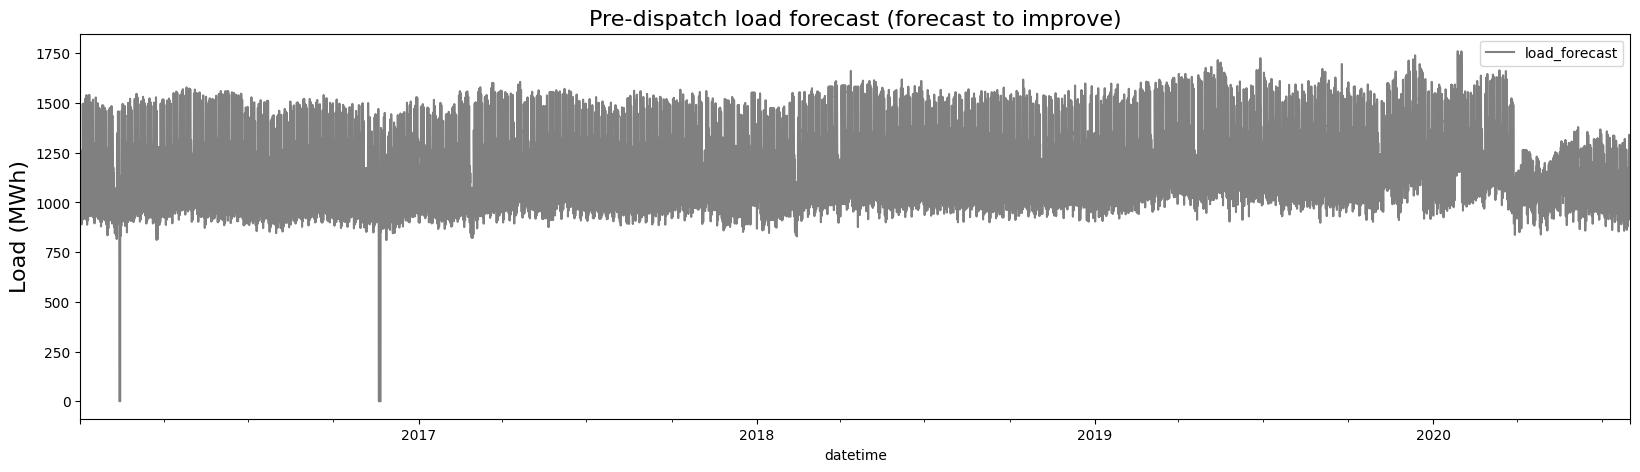

In [4]:
# set the working directory
# os.chdir(import_dir)

# csv file with load forecast to improve (weekly pre-dispatch)
filename = 'weekly pre-dispatch forecast.csv'

# Read the file and convert into "pre_disp_df" 
pre_disp_df = pd.read_csv(filename)

# set datetime as index
pre_disp_df.set_index('datetime', inplace=True)

# converting the index as date
pre_disp_df.index = pd.to_datetime(pre_disp_df.index)

# plot weekly pre-dispatch forecast (forecast to improve)
pre_disp_df.plot(figsize=(20,5), color='grey')
plt.title('Pre-dispatch load forecast (forecast to improve)', fontsize=16)
plt.ylabel('Load (MWh)', fontsize=16);

In [5]:
# set the working directory
# os.chdir(import_dir)

# Import a dictionary with all the training dataframes
# Use parameter sheet_name=None, from pd.read_excel
# to return a dictionary of Dataframes, with the sheet_names as dictionary keys.
train_dict = pd.read_excel(open('train_dataframes.xlsx', 'rb'), sheet_name = None, index_col=0)

# Import a dictionary with all the testing dataframes
test_dict = pd.read_excel(open('test_dataframes.xlsx', 'rb'), sheet_name = None, index_col=0)

In [6]:
# Get the keys from 'test_dict' dictionary
# keys are the same for both 'test_dict' and 'train_dict'
keys = list(test_dict.keys())

# Show keys
keys

['Week 15, Apr 2019',
 'Week 21, May 2019',
 'Week 24, Jun 2019',
 'Week 29, Jul 2019',
 'Week 33, Aug 2019',
 'Week 37, Sep 2019',
 'Week 41, Oct 2019',
 'Week 44, Nov 2019',
 'Week 51, Dec 2019',
 'Week 01, Jan 2020',
 'Week 06, Feb 2020',
 'Week 10, Mar 2020',
 'Week 20, May 2020',
 'Week 24, Jun 2020']

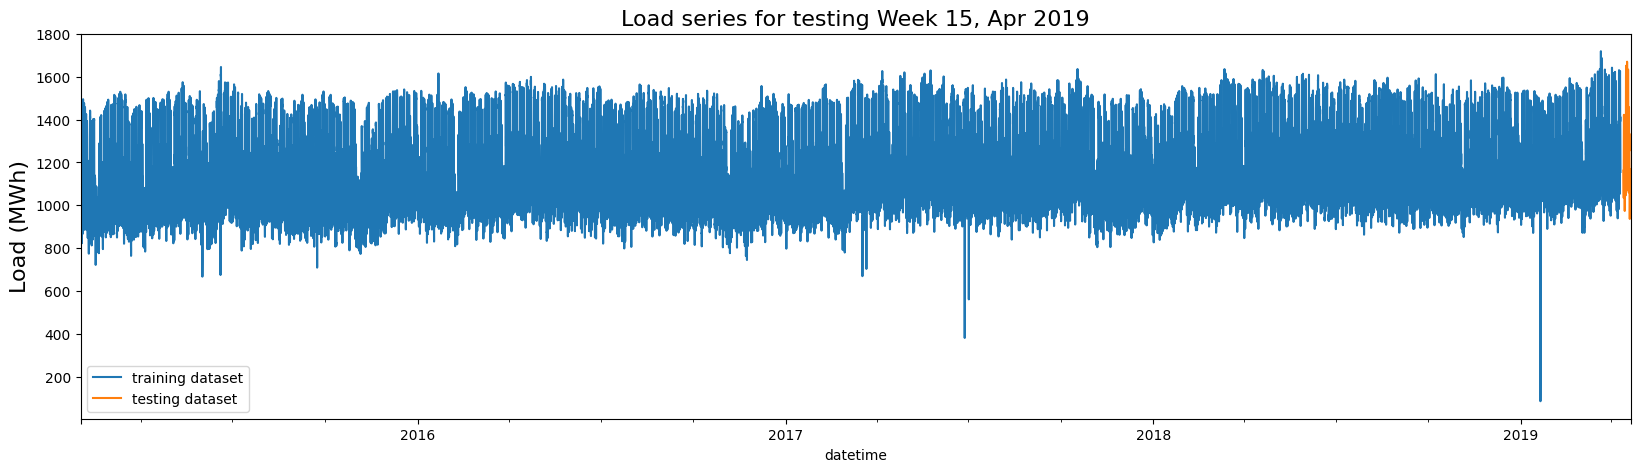

In [7]:
# Plot the electricity load, just for the first training/testing pair 
# notice the small gap between the two series, it's the 72 hours gap
train_dict[keys[0]]['DEMAND'].plot(figsize=(20,5), label='training dataset')
test_dict[keys[0]]['DEMAND'].plot(figsize=(20,5), label='testing dataset')
plt.ylabel('Load (MWh)', fontsize=16)
plt.title('Load series for testing ' + keys[0],fontsize=16)
plt.legend();

In [8]:
################################################################################
# ------------------------- MAPE evaluation functions --------------------------
################################################################################

# Define a function to calculate WEEKLY Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred): 
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return round(np.mean(np.abs((y_true - y_pred) / y_true)) * 100, 2)

# Define a function to calculate HOURLY Mean Absolute Percentage Error (MAPE)
def H_mean_absolute_percentage_error(y_true, y_pred): 
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    H_MAPE = (np.abs((y_true - y_pred) / y_true) * 100)
    rounded_H_MAPE = [round(num, 1) for num in H_MAPE]
    return rounded_H_MAPE

In [9]:
################################################################################
# ------------------ Time-based train and test splitting -----------------------
################################################################################
# Reference:
# https://towardsdatascience.com/time-based-cross-validation-d259b13d42b8
import pandas as pd
import datetime
from datetime import datetime as dt
from dateutil.relativedelta import *

class TimeBasedCV(object):
    '''
    Parameters 
    ----------
    train_period: int
        number of time units to include in each train set
        default is 30
    test_period: int
        number of time units to include in each test set
        default is 7
    freq: string
        frequency of input parameters. possible values are: days, months, years, weeks, hours, minutes, seconds
        possible values designed to be used by dateutil.relativedelta class
        deafault is days
    '''
    
    
    def __init__(self, train_period=30, test_period=7, freq='days'):
        self.train_period = train_period
        self.test_period = test_period
        self.freq = freq

        
        
    def split(self, data, validation_split_date=None, date_column='record_date', gap=0):
        '''
        Generate indices to split data into training and test set
        
        Parameters 
        ----------
        data: pandas DataFrame
            your data, contain one column for the record date 
        validation_split_date: datetime.date()
            first date to perform the splitting on.
            if not provided will set to be the minimum date in the data after the first training set
        date_column: string, deafult='record_date'
            date of each record
        gap: int, default=0
            for cases the test set does not come right after the train set,
            *gap* days are left between train and test sets
        
        Returns 
        -------
        train_index ,test_index: 
            list of tuples (train index, test index) similar to sklearn model selection
        '''
        
        # check that date_column exist in the data:
        try:
            data[date_column]
        except:
            raise KeyError(date_column)
                    
        train_indices_list = []
        test_indices_list = []

        if validation_split_date==None:
            validation_split_date = data[date_column].min().date() + eval('relativedelta('+self.freq+'=self.train_period)')
        
        start_train = validation_split_date - eval('relativedelta('+self.freq+'=self.train_period)')
        end_train = start_train + eval('relativedelta('+self.freq+'=self.train_period'+'-gap)')
        start_test = end_train + eval('relativedelta('+self.freq+'=gap)')
        end_test = start_test + eval('relativedelta('+self.freq+'=self.test_period)')

        while end_test < data[date_column].max().date():
            # train indices:
            cur_train_indices = list(data[(data[date_column].dt.date>=start_train) & 
                                     (data[date_column].dt.date<end_train)].index)

            # test indices:
            cur_test_indices = list(data[(data[date_column].dt.date>=start_test) &
                                    (data[date_column].dt.date<end_test)].index)
            
            print("Train period:",start_train,"-" , end_train, ", Test period", start_test, "-", end_test,
                  "# train records", len(cur_train_indices), ", # test records", len(cur_test_indices))

            train_indices_list.append(cur_train_indices)
            test_indices_list.append(cur_test_indices)

            # update dates:
            start_train = start_train + eval('relativedelta('+self.freq+'=self.test_period)')
            end_train = start_train + eval('relativedelta('+self.freq+'=self.train_period'+'-gap)')
            start_test = end_train + eval('relativedelta('+self.freq+'=gap)')
            end_test = start_test + eval('relativedelta('+self.freq+'=self.test_period)')

        # mimic sklearn output  
        index_output = [(train,test) for train,test in zip(train_indices_list,test_indices_list)]

        self.n_splits = len(index_output)
        
        return index_output
    
    
    def get_n_splits(self):
        """Returns the number of splitting iterations in the cross-validator
        Returns
        -------
        n_splits : int
            Returns the number of splitting iterations in the cross-validator.
        """
        return self.n_splits 

In [10]:
################################################################################
# ------------------- Plotting test and demand forecast  -----------------------
################################################################################

def plot_test_forecast(y_test, y_pred_test, y_pre_disp):
    import matplotlib.pyplot as plt
    import matplotlib.ticker as mticker
    from matplotlib.ticker import MaxNLocator
    import numpy as np

    # Calculate values to plot
    delta_demand = y_test - y_pred_test
    
    # Assuming H_mean_absolute_percentage_error returns array of same length as inputs
    H_MAPE = H_mean_absolute_percentage_error(y_test, y_pred_test)
    
    # Define x-axis based on length of y_test
    x_vals = np.arange(len(y_test))

    fig, (ax, bx) = plt.subplots(1, 2, figsize=(20, 5))
    plt.rc('xtick', labelsize=12)
    plt.rc('ytick', labelsize=12)

    # First plot: Real demand vs Forecasts
    ax.plot(x_vals, y_test, c='green', label='Real Demand')
    ax.plot(x_vals, y_pred_test, c='red', label='Demand Forecast')
    ax.plot(x_vals, y_pre_disp, c='gray', linestyle='--', label='Pre-dispatch Forecast')
    ax.get_yaxis().set_major_formatter(mticker.FuncFormatter(lambda x, p: format(int(x), ',')))
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_xlabel('Hours of the week', fontsize=12)
    ax.set_ylabel('MWh', rotation=0, fontsize=12, labelpad=20)
    ax.set_title('Real demand vs Forecasts')

    # Second plot: Forecast errors and MAPE
    bx.bar(x_vals, delta_demand, width=1.0, color='grey', label='Error')
    bx.xaxis.set_major_locator(MaxNLocator(integer=True))
    bx.set_xlabel('Hours of the week', fontsize=12)
    bx.set_ylabel('MWh', rotation=0, fontsize=12, labelpad=5)
    bx.get_yaxis().set_major_formatter(mticker.FuncFormatter(lambda x, p: format(int(x), ',')))
    bx2 = bx.twinx()  # Secondary y-axis for MAPE

    legend = ax.legend(loc='lower left', fontsize=12)
    bx.set_title('Forecast errors and MAPE')

    # Calculate baseline weekly MAPE (for pre-dispatch forecast)
    MAPE2improve = mean_absolute_percentage_error(y_test, y_pre_disp)

    color = 'tab:blue'
    bx2.set_ylabel('MAPE', color=color, labelpad=20, rotation=0, fontsize=12)

    # Plot H_MAPE: check if array or scalar and plot accordingly
    if hasattr(H_MAPE, '__len__') and len(H_MAPE) == len(x_vals):
        bx2.plot(x_vals, H_MAPE, color=color, label='Absolute Error (%)')
    else:
        # Scalar: plot constant line
        bx2.plot(x_vals, [H_MAPE]*len(x_vals), color=color, label='Absolute Error (%)')

    bx2.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
    bx2.tick_params(axis='y', labelcolor=color)
    bx2.set_ylim(bottom=0)

    # Horizontal line showing baseline error cap
    plt.axhline(y=MAPE2improve, color='k', linestyle='--', label=f'Error cap ({MAPE2improve}%)')

    legend = bx.legend(loc='upper left', fontsize=12)
    legend = bx2.legend(loc='upper right', fontsize=12)

    fig.tight_layout()
    plt.show()


In [11]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, Dense, Flatten, Dropout, concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

def create_multiheaded_cnn_model(n_heads, filters, kernel_size, dropout_rate, learning_rate, input_shape):
    inputs = Input(shape=input_shape)

    conv_heads = []
    for _ in range(n_heads):
        x = Conv1D(filters=filters, kernel_size=kernel_size, activation='relu', padding='same')(inputs)
        x = Dropout(dropout_rate)(x)
        x = Flatten()(x)
        conv_heads.append(x)

    if n_heads > 1:
        x = concatenate(conv_heads)
    else:
        x = conv_heads[0]

    x = Dense(64, activation='relu')(x)
    outputs = Dense(1)(x)  # regression output

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')
    return model

def model_hyperparameter_search(trial, X_train_val, y_train_val):
    # Define hyperparameters to tune
    n_heads = trial.suggest_int('n_heads', 1, 3)
    filters = trial.suggest_categorical('filters', [16, 32, 64])
    kernel_size = trial.suggest_int('kernel_size', 2, 5)
    dropout_rate = trial.suggest_float('dropout_rate', 0.0, 0.5)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)

    input_shape = (X_train_val.shape[1], X_train_val.shape[2])

    model = create_multiheaded_cnn_model(
        n_heads=n_heads,
        filters=filters,
        kernel_size=kernel_size,
        dropout_rate=dropout_rate,
        learning_rate=learning_rate,
        input_shape=input_shape
    )

    early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    history = model.fit(
        X_train_val, y_train_val,
        epochs=30,
        batch_size=64,
        validation_split=0.2,
        callbacks=[early_stopping],
        verbose=0
    )

    val_loss = min(history.history['val_loss'])
    return val_loss  # Optuna minimizes the validation loss by default


In [12]:
import optuna
from optuna.samplers import TPESampler

def train_model(X_train_val, y_train_val, random_state=42, n_trials=30):
    # Define objective with data explicitly passed
    def objective(trial):
        return model_hyperparameter_search(trial, X_train_val, y_train_val)

    # Create study - direction should be 'minimize' because model_hyperparameter_search returns validation loss
    study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=random_state))
    study.optimize(objective, n_trials=n_trials, n_jobs=1)

    best_params = study.best_trial.params

    # Build best model with best hyperparameters
    best_model = create_multiheaded_cnn_model(
        n_heads=best_params['n_heads'],
        filters=best_params['filters'],
        kernel_size=best_params['kernel_size'],
        dropout_rate=best_params['dropout_rate'],
        learning_rate=best_params['learning_rate'],
        input_shape=(X_train_val.shape[1], X_train_val.shape[2])
    )

    # Train best model fully with more epochs (you may add callbacks like EarlyStopping here too)
    best_model.fit(X_train_val, y_train_val, epochs=30, batch_size=64, verbose=1)

    return best_model, study


[I 2025-07-15 11:40:29,495] A new study created in memory with name: no-name-8ce856d1-72b9-4cb9-8509-2b89553188d2


✅ Created test windows: 167 samples


[I 2025-07-15 11:41:04,312] Trial 0 finished with value: 8018.53271484375 and parameters: {'n_heads': 2, 'filters': 16, 'kernel_size': 2, 'dropout_rate': 0.07799726016810132, 'learning_rate': 0.00013066739238053285}. Best is trial 0 with value: 8018.53271484375.
[I 2025-07-15 11:41:36,403] Trial 1 finished with value: 7297.033203125 and parameters: {'n_heads': 3, 'filters': 32, 'kernel_size': 5, 'dropout_rate': 0.41622132040021087, 'learning_rate': 0.00026587543983272726}. Best is trial 1 with value: 7297.033203125.
[I 2025-07-15 11:41:56,909] Trial 2 finished with value: 6426.68017578125 and parameters: {'n_heads': 1, 'filters': 64, 'kernel_size': 3, 'dropout_rate': 0.14561457009902096, 'learning_rate': 0.0016738085788752138}. Best is trial 2 with value: 6426.68017578125.
[I 2025-07-15 11:42:17,216] Trial 3 finished with value: 6581.69677734375 and parameters: {'n_heads': 1, 'filters': 64, 'kernel_size': 5, 'dropout_rate': 0.09983689107917987, 'learning_rate': 0.0010677482709481358}. 

Epoch 1/30
574/574 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 798587.8750
Epoch 2/30
574/574 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 14013.9707
Epoch 3/30
574/574 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 10887.2559
Epoch 4/30
574/574 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 8756.9287
Epoch 5/30
574/574 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 8007.4702
Epoch 6/30
574/574 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 7472.9097
Epoch 7/30
574/574 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7332.1177
Epoch 8/30
574/574 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 6734.9385
Epoch 9/30
574/574 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 6587.6270
Epoch 10/30
574/574 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 6361.8140
Epoch 11/30
574/574 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 6248.1328
Epoch 12/30
574/574 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 6191.2925
Epoch 13/30
574/574 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5973.2432
Epoch 14/30
574/574 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 5997.2944
Epoch 15/30

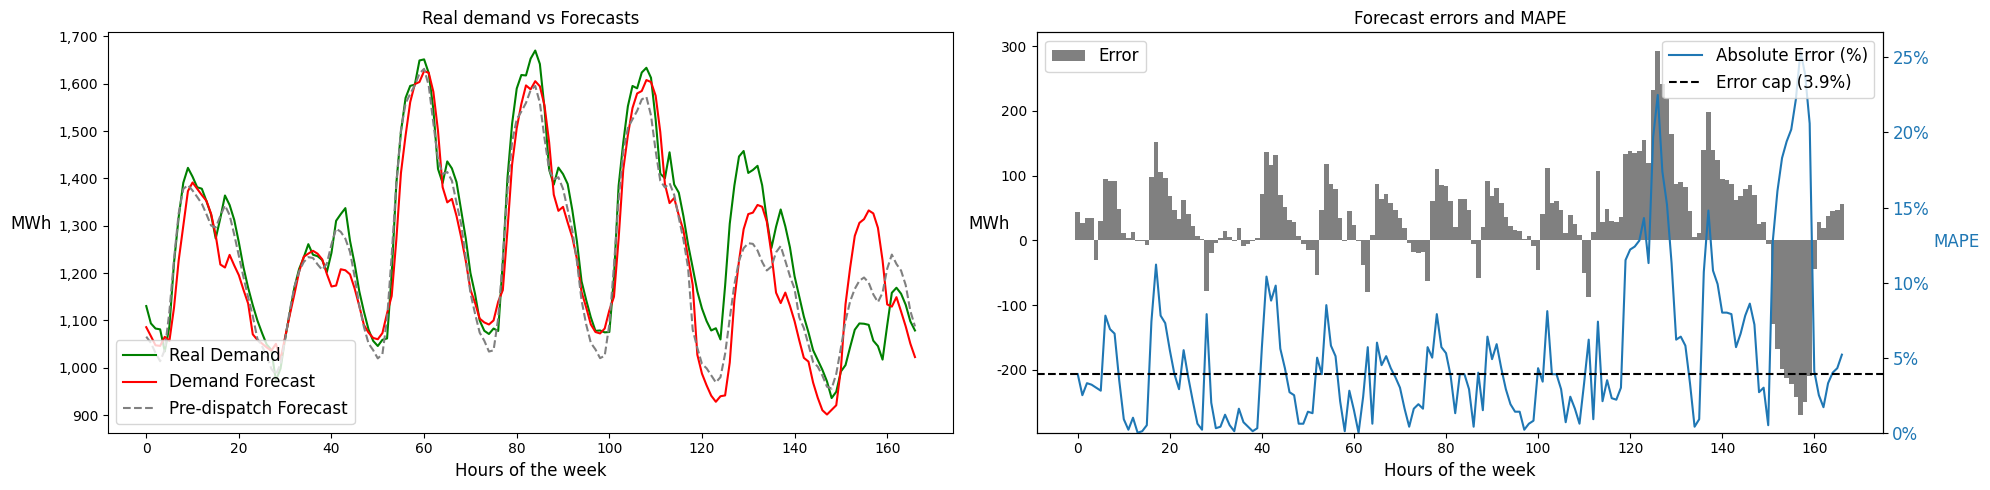

In [13]:
import os
import joblib
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import load_model

window_size = 1  # sliding window length (e.g. 1 hour)

def create_sliding_windows(df, window_size=window_size):
    X_windows = []
    y_windows = []
    for i in range(len(df) - window_size):
        X_windows.append(df.iloc[i:i+window_size].drop(columns=['DEMAND']).values)
        y_windows.append(df['DEMAND'].iloc[i + window_size])
    return np.array(X_windows), np.array(y_windows)

for key in keys[:1]:  # or use full keys list
    train_df = train_dict[key].copy()
    test_df = test_dict[key].copy()

    # ----------- Scaling features (except 'DEMAND') -----------
    features = train_df.columns.drop('DEMAND')

    scaler = MinMaxScaler()

    # Fit scaler on train features only
    train_df[features] = scaler.fit_transform(train_df[features])

    # Transform test features with the same scaler
    test_df[features] = scaler.transform(test_df[features])

    # ----------- Create sliding windows -----------
    X_train_val, y_train_val = create_sliding_windows(train_df)
    
    if len(test_df) >= window_size + 1:
        X_test, y_test = create_sliding_windows(test_df)
        y_test_index = test_df.index[window_size:]
        y_test = pd.Series(y_test, index=y_test_index, name='DEMAND')
        print(f"✅ Created test windows: {X_test.shape[0]} samples")
    else:
        print(f"❌ Not enough data in test week '{key}' (only {len(test_df)} rows). Skipping test set.")
        X_test, y_test = np.array([]), pd.Series([], dtype=float)

    # ----------- Train the CNN model with Optuna tuning -----------
    generic_model, generic_model_study = train_model(X_train_val, y_train_val)

    # ----------- Save model and study safely -----------
    models_dir = './models'
    os.makedirs(models_dir, exist_ok=True)

    safe_key = key.replace(' ', '_').replace(',', '')  # sanitize filename

    model_path = os.path.join(models_dir, f'cnn_model_{safe_key}.keras')
    generic_model.save(model_path)
    print(f"✅ Model saved at {model_path}")

    study_path = os.path.join(models_dir, f'cnn_study_{safe_key}.pkl')
    joblib.dump(generic_model_study, study_path)
    print(f"✅ Optuna study saved at {study_path}")

    # ----------- Predict and evaluate -----------
    print("✅ X_train_val shape:", X_train_val.shape)
    print("✅ X_test shape:", X_test.shape)

    y_pred_train = generic_model.predict(X_train_val).flatten()
    RMSE_train_score = round(np.sqrt(mean_squared_error(y_train_val, y_pred_train)), 2)
    MAPE_train_score = round(mean_absolute_percentage_error(y_train_val, y_pred_train), 2)

    if X_test.shape[0] > 0:
        y_pred_test = generic_model.predict(X_test).flatten()

        # Align indices and lengths for safe evaluation
        y_test.index = pd.to_datetime(y_test.index).round("H")
        pre_disp_df.index = pd.to_datetime(pre_disp_df.index).round("H")

        # Merge with pre-dispatch forecast
        try:
            y_pre_disp = pd.merge(
                y_test,
                pre_disp_df['load_forecast'],
                how='inner',
                left_index=True,
                right_index=True
            )['load_forecast']
        except Exception as e:
            print("❌ Merge failed:", e)
            y_pre_disp = pd.Series(dtype=float)

        # Ensure prediction and true values have the same length to avoid errors
        min_len = min(len(y_test), len(y_pred_test))
        y_test_eval = y_test.iloc[:min_len]
        y_pred_eval = y_pred_test[:min_len]

        if len(y_pre_disp) == len(y_test_eval):
            MAPE2improve = mean_absolute_percentage_error(y_test_eval, y_pre_disp)
            RMSE2improve = round(np.sqrt(mean_squared_error(y_test_eval, y_pre_disp)), 2)

            RMSE_test_score = round(np.sqrt(mean_squared_error(y_test_eval, y_pred_eval)), 2)
            MAPE_test_score = round(mean_absolute_percentage_error(y_test_eval, y_pred_eval), 2)

            print("\n📊 Model Evaluation:")
            print('Train RMSE:', RMSE_train_score, 'MWh')
            print('Test  RMSE:', RMSE_test_score,  'MWh')
            print('Train MAPE:', MAPE_train_score, '%')
            print('Test  MAPE:', MAPE_test_score,  '%')
            print('🟡 RMSE to improve (baseline):', RMSE2improve, 'MWh')
            print('🟡 MAPE to improve (baseline):', MAPE2improve, '%')

            plot_test_forecast(y_test_eval, y_pred_eval, y_pre_disp)

        else:
            print("\n⚠️ Warning: Could not compare with pre-dispatch forecast (timestamp mismatch).")
            print('Train RMSE:', RMSE_train_score, 'MWh')
            print('Train MAPE:', MAPE_train_score, '%')

    else:
        print("\n❌ X_test is empty — not enough data for prediction.")
        print("➡️ Please check the test dataset size or adjust the window size.")


In [14]:
import os
import re
import joblib

# Ensure the models directory exists
os.makedirs("models", exist_ok=True)

# Sanitize the key to be safe for filenames (replace non-word characters by underscore)
safe_key = re.sub(r'[^\w\-]', '_', key)

# Save the Keras model (HDF5 format)
model_path = os.path.join('models', f'cnn_model_{safe_key}.h5')
generic_model.save(model_path)

# Save the Optuna study object
study_path = os.path.join('models', f'cnn_study_{safe_key}.pkl')
joblib.dump(generic_model_study, study_path)

print(f"✅ Model saved at: {model_path}")
print(f"✅ Optuna study saved at: {study_path}")




✅ Model saved at: models\cnn_model_Week_15__Apr_2019.h5
✅ Optuna study saved at: models\cnn_study_Week_15__Apr_2019.pkl


✅ X_train_val shape: (36719, 1, 10)
✅ X_test shape: (167, 1, 10)
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

📊 Model Evaluation:
Train RMSE: 67.62 MWh
Test  RMSE: 90.36 MWh
Train MAPE: 4.51 %
Test  MAPE: 5.36 %
🟡 RMSE to improve (baseline): 65.04 MWh
🟡 MAPE to improve (baseline): 3.9 %


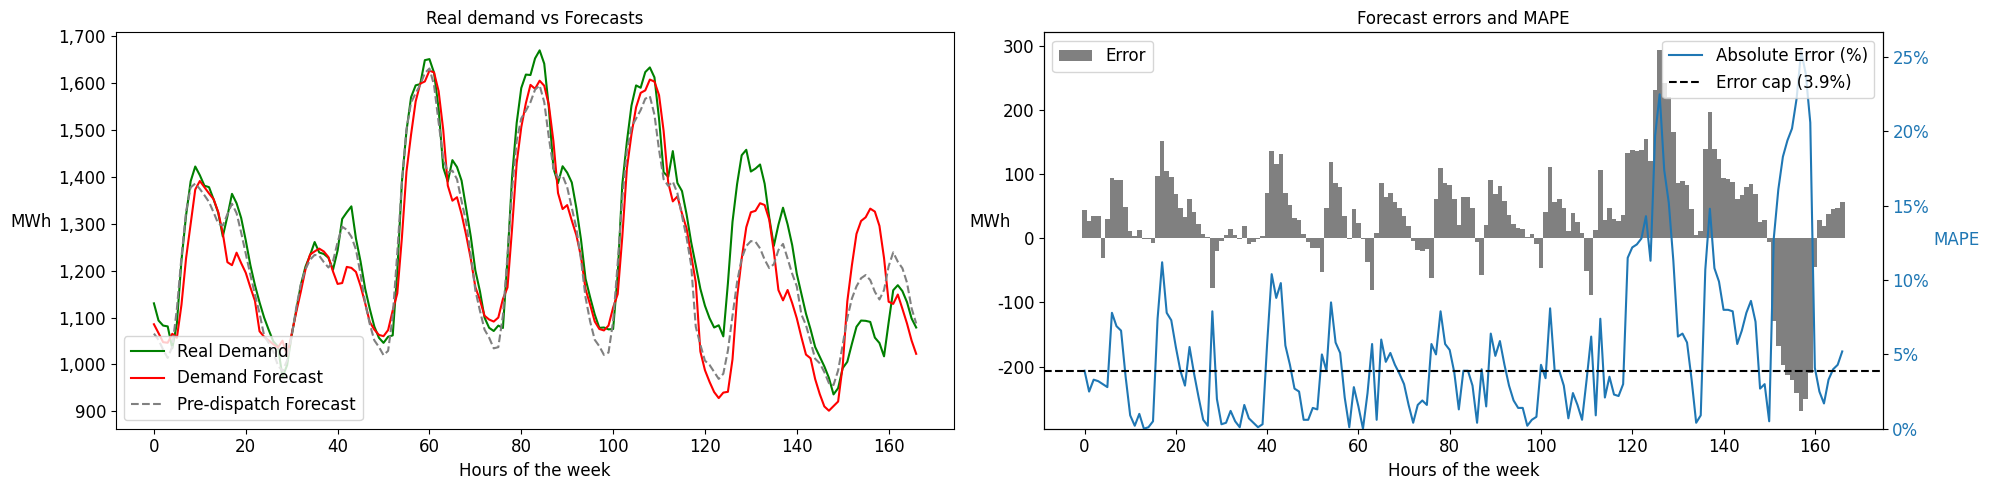

In [15]:
# ------------------ Predict and Evaluate CNN Model ------------------

print("✅ X_train_val shape:", X_train_val.shape)
print("✅ X_test shape:", X_test.shape)

# Predict on training set
y_pred_train = generic_model.predict(X_train_val).flatten()
RMSE_train_score = round(np.sqrt(mean_squared_error(y_train_val, y_pred_train)), 2)
MAPE_train_score = round(mean_absolute_percentage_error(y_train_val, y_pred_train), 2)

if X_test.shape[0] > 0:
    y_pred_test = generic_model.predict(X_test).flatten()

    # Make sure y_test is a Series with datetime index and a name
    if not hasattr(y_test, 'name') or y_test.name is None:
        y_test.name = 'DEMAND'

    y_test.index = pd.to_datetime(y_test.index).round("H")
    pre_disp_df.index = pd.to_datetime(pre_disp_df.index).round("H")

    # Merge y_test and pre_dispatch forecast on index
    try:
        y_pre_disp = pd.merge(
            y_test, 
            pre_disp_df['load_forecast'], 
            how='inner', 
            left_index=True, 
            right_index=True
        )['load_forecast']
    except Exception as e:
        print("❌ Merge failed:", e)
        y_pre_disp = pd.Series(dtype=float)

    if len(y_pre_disp) == len(y_test):
        MAPE2improve = mean_absolute_percentage_error(y_test, y_pre_disp)
        RMSE2improve = round(np.sqrt(mean_squared_error(y_test, y_pre_disp)), 2)

        RMSE_test_score = round(np.sqrt(mean_squared_error(y_test, y_pred_test)), 2)
        MAPE_test_score = round(mean_absolute_percentage_error(y_test, y_pred_test), 2)

        print("\n📊 Model Evaluation:")
        print('Train RMSE:', RMSE_train_score, 'MWh')
        print('Test  RMSE:', RMSE_test_score,  'MWh')
        print('Train MAPE:', MAPE_train_score, '%')
        print('Test  MAPE:', MAPE_test_score,  '%')
        print('🟡 RMSE to improve (baseline):', RMSE2improve, 'MWh')
        print('🟡 MAPE to improve (baseline):', MAPE2improve, '%')

        plot_test_forecast(y_test, y_pred_test, y_pre_disp)

    else:
        print("\n⚠️ Warning: Could not compare with pre-dispatch forecast (timestamp mismatch).")
        print('Train RMSE:', RMSE_train_score, 'MWh')
        print('Train MAPE:', MAPE_train_score, '%')

else:
    print("\n❌ X_test is empty — not enough data for prediction.")
    print("➡️ Please check the test dataset size or adjust the window size.")


In [16]:
# Visualize the optimization progress along the trials
optuna.visualization.plot_optimization_history(generic_model_study)

In [17]:
# Visualize the optimization progress by parameter
optuna.visualization.plot_slice(generic_model_study)

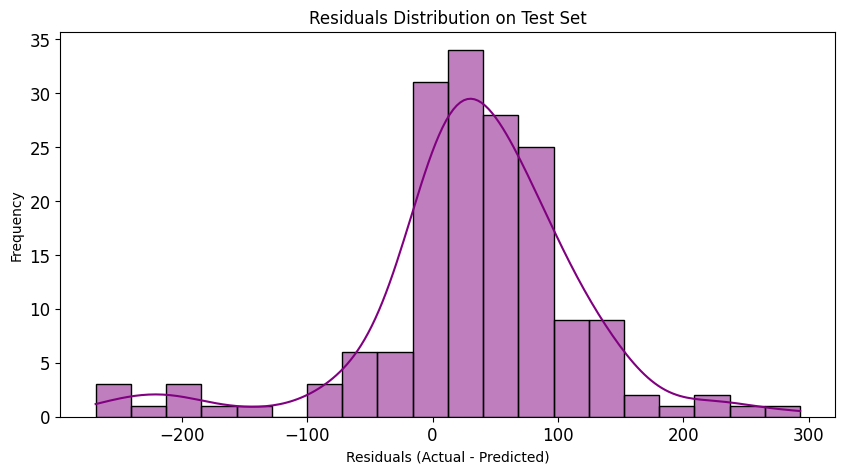

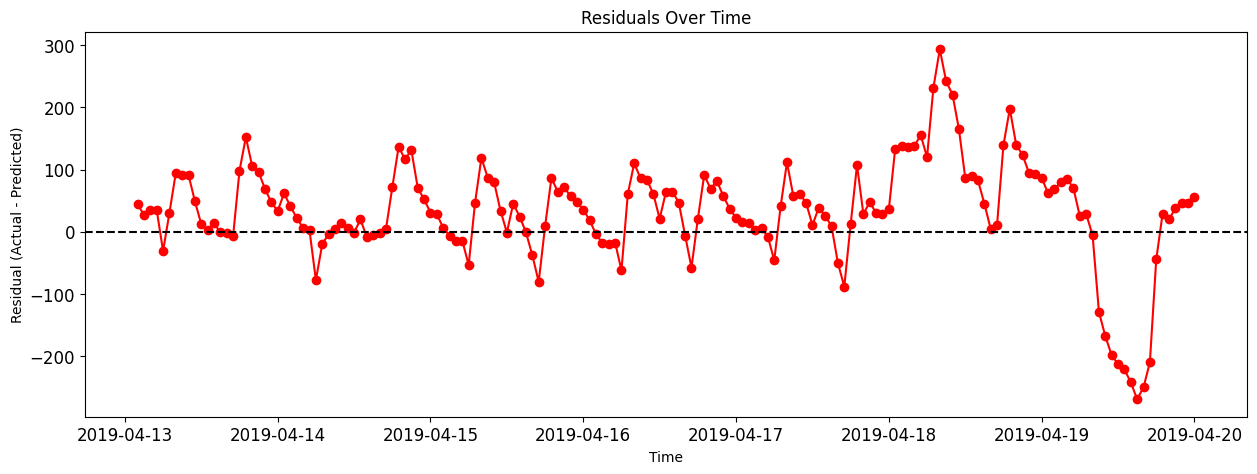

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate residuals
residuals = y_test - y_pred_test

# Plot residuals distribution
plt.figure(figsize=(10,5))
sns.histplot(residuals, kde=True, color='purple')
plt.title('Residuals Distribution on Test Set')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.show()

# Plot residuals over time
plt.figure(figsize=(15,5))
plt.plot(y_test.index, residuals, marker='o', linestyle='-', color='red')
plt.title('Residuals Over Time')
plt.xlabel('Time')
plt.ylabel('Residual (Actual - Predicted)')
plt.axhline(0, color='black', linestyle='--')
plt.show()
